# Étape 1 - Collecte, appariement et préparation des données

**Corpus :** Professions de foi des législatives 1993 (corpus Archelec / CEVIPOF)  
**Objectif :** Construire un DataFrame complet textes+métadonnées, nettoyer les textes, et produire une analyse descriptive initiale.

# 0.Imports

In [ ]:
#pip install spacy
#python -m spacy download fr_core_news_sm
#python -m spacy download fr_core_news_md
#pip install wordcloud
#pip install collection

SyntaxError: invalid syntax (2720595791.py, line 3)

In [5]:
pip install spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.8/32.8 MB 82.1 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.9/839.9 kB 51.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 57.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 87.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22/22 [spacy]m21/22 [spacy]gue]
Note: you may need to restart the kernel to use updated packages.


In [6]:
import re
import json
import random
from pathlib import Path
from io import TextIOWrapper
from zipfile import ZipFile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import spacy

random.seed(45)
np.random.seed(45)

# Paths (adjust if needed)
DATA_DIR = Path("../data")
ZIP_1993 = DATA_DIR / "legislatives_1993.zip"
META_CSV = DATA_DIR / "meta_archelect_1993.csv"

print("ZIP exists:", ZIP_1993.exists())
print("Meta CSV exists:", META_CSV.exists())

ZIP exists: True
Meta CSV exists: True


# 1. Chargement des textes

Les fichiers `.txt` du zip sont issus d'une OCR. On conserve l'identifiant de chaque document (nom du fichier sans extension) pour l'appariement ultérieur avec les métadionnées. 

**Remarque :** Certains fichiers du zip se terminent par `_BV_pdfmasterocr`. Ce sont des *biulletins de vote*, hors périmètre. Nous conservons donc juste les 5842 fichiers de professions de foi appariables au csv.

In [7]:
records = {}

with ZipFile(ZIP_1993) as zf:
    for name in zf.namelist():
        if not name.endswith(".txt"):
            continue
        doc_id = Path(name).stem
        # Exclure les bulletins de vote
        if doc_id.endswith("_BV_pdfmasterocr"):
            continue
        with zf.open(name) as f:
            try:
                txt = TextIOWrapper(f, encoding="utf-8", errors="replace").read()
            except Exception:
                f.seek(0)
                txt = TextIOWrapper(f, encoding="latin-1", errors="replace").read()
            records[doc_id] = txt

print(f"{len(records)} professions de foi chargées")

5842 professions de foi chargées


# 2. Appariement avec les métadonnées

Le csv `meta_archelect_1993.csv` contient les métadonnées Archelec : parti (soutien), âge, etc. L'identifiant commun est le champ `id`. 

In [15]:
df_meta = pd.read_csv(META_CSV)
df_texts = pd.DataFrame({"id": list(records.keys()), "raw_text": list(records.values())})

df = df_meta.merge(df_texts, on="id", how="inner")

df.head(10)

,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,raw_text
0,EL189_L_1993_03_001_01_1_PF_01,1993-03-21,France;Ve République;Assemblée Nationale;Élect...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 50 et 59 ans,gendarme,non mentionné,non mentionné,professionnel,retraité,Front national,non mentionné,non,ELECTIONS LEGISLATIVES DE MARS 93\nFRONT NATIO...
1,EL189_L_1993_03_001_01_1_PF_02,1993-03-21,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,non mentionné,agent territorial,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné,non,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...
2,EL189_L_1993_03_001_01_1_PF_03,1993-03-21,Assemblée Nationale;Élections législatives;Ve ...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,non mentionné,non mentionné,maire;conseiller général,non mentionné,non mentionné,non mentionné,Union pour la démocratie française;Rassembleme...,non mentionné,oui,Sciences Po / fonds CEVIPOF\nElections législa...
3,EL189_L_1993_03_001_01_1_PF_04,1993-03-21,Élections législatives;Assemblée Nationale;Fra...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 40 et 49 ans,enseignant lycée d'enseignement professionnel,non mentionné,non mentionné,non mentionné,non mentionné,Lutte ouvrière,non mentionné,non,Elections législatives du 21 mars 1993\nPourqu...
4,EL189_L_1993_03_001_01_1_PF_05,1993-03-21,Ve République;Élections législatives;France;As...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 20 et 29 ans,non mentionné,non mentionné,non mentionné,non mentionné,étudiant,Verts;Génération écologie,Entente des écologistes,non,Sciences Po / fonds CEVIPOF\nRépublique França...
5,EL189_L_1993_03_001_01_1_PF_06,1993-03-21,Ve République;Assemblée Nationale;Élections lé...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 30 et 39 ans,éducateur spécialisé foyer adolescents,non mentionné,non mentionné,syndicat,célibataire,Ligue communiste révolutionnaire;Alternative r...,non mentionné,non,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...
6,EL189_L_1993_03_001_01_1_PF_07,1993-03-21,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non,Sciences Po / fonds CEVIPOF\nAgir ensemble\nEc...
7,EL189_L_1993_03_001_01_1_PF_08,1993-03-21,Élections législatives;Ve République;Assemblée...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,non mentionné,adjoint administratif,non mentionné,non mentionné,non mentionné,non mentionné,Nouveaux écologistes du rassemblement nature e...,non mentionné,non,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...
8,EL189_L_1993_03_001_02_1_PF_01,1993-03-21,Ve République;Assemblée Nationale;France;Élect...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 60 et 69 ans,non mentionné,non mentionné,non mentionné,non mentionné,retraité,Front national,non mentionné,non,ELECTIONS LEGISLATIVES DE MARS 93\nFRONT NATIO...
9,EL189_L_1993_03_001_02_1_PF_02,1993-03-21,Élections législatives;Ve République;France;As...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 40 et 49 ans,agent de maîtrise EDF,non mentionné,non mentionné,non mentionné,non mentionné,P

In [9]:
print(f"Documents après appariement : {len(df)}")
print(f"Nombre de colonnes : {len(df.columns)}")
print(f"Colonnes disponibles : {df.columns.tolist()}")


Documents après appariement : 5837
Nombre de colonnes : 43
Colonnes disponibles : ['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour', 'cote', 'departement', 'departement-nom', 'departement-insee', 'identifiant de circonscription', 'images', 'pdf', 'ocr_url', 'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age', 'titulaire-age-calcule', 'titulaire-age-tranche', 'titulaire-profession', 'titulaire-mandat-en-cours', 'titulaire-mandat-passe', 'titulaire-associations', 'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste', 'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom', 'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule', 'suppleant-age-tranche', 'suppleant-profession', 'suppleant-mandat-en-cours', 'suppleant-mandat-passe', 'suppleant-associations', 'suppleant-autres-statuts', 'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations', 'raw_text']


# 3. 'Normalisation' de la variable de soutien

La colonne `titulaire-soutien` contient parfois plusieurs partis séparés par `;` (coalitions). 

In [10]:
df["titulaire-soutien"].value_counts().tail(20)
#df["titulaire-soutien"].head(8)

titulaire-soutien
aucune formation politique                                                                                                                   1
Amis de la Terre                                                                                                                             1
indépendant;écologiste                                                                                                                       1
Solidarités;A gauche autrement                                                                                                               1
Parti communiste français;Alternative rouge et verte;Refondations;Convergences et démocratie;Espoirs 93;Alternative démocratie socialisme    1
Alternative démocratie socialisme                                                                                                            1
Union pour la démocratie française;Parti républicain;Centre des démocrates sociaux;Parti social démocrate;Parti radical     

In [16]:
import unicodedata
# test for new coding
# ============================================================
# 1. Fonctions de normalisation
# ============================================================

def strip_accents(text):
    """
    Supprime les accents pour faciliter les comparaisons.
    Exemple : 'Écologie' -> 'Ecologie'
    """
    if pd.isna(text):
        return ""
    text = str(text)
    return "".join(
        char for char in unicodedata.normalize("NFKD", text)
        if not unicodedata.combining(char)
    )


def normalize_support(text):
    """
    Normalise une chaîne de soutien politique :
    - minuscules
    - suppression accents
    - espaces homogènes
    - séparateurs ';' homogènes
    """
    if pd.isna(text) or str(text).strip() == "":
        return "non mentionne"

    text = strip_accents(str(text))
    text = text.lower()
    text = text.replace("’", "'").replace("`", "'")
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s*;\s*", ";", text)
    text = text.strip()

    return text


def split_supports(text):
    """
    Découpe une modalité de soutien en liste de soutiens élémentaires.
    Exemple :
    'RPR;UDF' -> ['rpr', 'udf']
    """
    text = normalize_support(text)

    if text in ["", "nan", "none", "non mentionne"]:
        return ["non mentionne"]

    parts = [part.strip() for part in text.split(";") if part.strip()]
    return parts if parts else ["non mentionne"]


# ============================================================
# 2. Classification d'une composante individuelle
# ============================================================

def classify_single_component(component):
    """
    Classe une composante individuelle de soutien dans une grande famille politique.

    Important :
    Cette fonction ne classe PAS encore l'ensemble du candidat.
    Elle classe seulement chaque élément séparé par ';'.

    Exemple :
    'Rassemblement pour la République' -> 'Droite parlementaire (RPR/UDF)'
    'Union pour la démocratie française' -> 'Droite parlementaire (RPR/UDF)'
    """

    c = normalize_support(component)

    # ----------------------------
    # Non renseigné
    # ----------------------------
    if c in ["", "nan", "none", "non mentionne"]:
        return "Non mentionné"

    # ----------------------------
    # Extrême gauche
    # À placer avant PCF car "Ligue communiste révolutionnaire"
    # contient le mot "communiste" mais ne doit pas être classée PCF.
    # ----------------------------
    extreme_gauche_patterns = [
        r"\blutte ouvriere\b",
        r"\bligue communiste revolutionnaire\b",
        r"\blcr\b",
        r"\bparti des travailleurs\b",
        r"\balliance europeenne des travailleurs\b",
        r"\bentente internationale des travailleurs\b",
        r"\bjeunesses communistes revolutionnaires\b",
        r"\balternative rouge et verte\b",
        r"\balternative democratie socialisme\b",
    ]

    if any(re.search(pattern, c) for pattern in extreme_gauche_patterns):
        return "Extrême gauche"

    # ----------------------------
    # Front national
    # ----------------------------
    front_national_patterns = [
        r"\bfront national\b",
        r"\bfn\b",
    ]

    if any(re.search(pattern, c) for pattern in front_national_patterns):
        return "Front national"

    # ----------------------------
    # PCF
    # ----------------------------
    pcf_patterns = [
        r"\bparti communiste francais\b",
        r"\bpcf\b",
        r"\bcommuniste\b",
    ]

    if any(re.search(pattern, c) for pattern in pcf_patterns):
        return "PCF"

    # ----------------------------
    # Droite parlementaire / centre-droit
    # ----------------------------
    droite_patterns = [
        r"\brassemblement pour la republique\b",
        r"\brpr\b",
        r"\bunion pour la democratie francaise\b",
        r"\budf\b",
        r"\bcentre des democrates sociaux\b",
        r"\bcds\b",
        r"\bcentre national des independants\b",
        r"\bcentre national des independants et paysans\b",
        r"\bcni\b",
        r"\bdemocratie chretienne francaise\b",
        r"\bparti republicain\b",
        r"\bmouvement des reformateurs\b",
        r"\bgaulliste\b",
        r"\bunion des democrates de progres\b",
        r"\bunion des democrates chretiens\b",
    ]

    if any(re.search(pattern, c) for pattern in droite_patterns):
        return "Droite parlementaire (RPR/UDF)"

    # ----------------------------
    # Gauche gouvernementale
    # PS / MRG / MDC
    # ----------------------------
    gauche_gouv_patterns = [
        r"\bparti socialiste\b",
        r"\bps\b",
        r"\bmouvement des radicaux de gauche\b",
        r"\bmrg\b",
        r"\bmouvement des citoyens\b",
        r"\bmdc\b",
        r"\bparti radical\b",
        r"\bsocialiste\b",
        r"\bsocialistes\b",
        r"\bparti social democrate\b",
    ]

    if any(re.search(pattern, c) for pattern in gauche_gouv_patterns):
        return "Gauche gouvernementale (PS/MRG/MDC)"

    # ----------------------------
    # Écologistes
    # ----------------------------
    ecologie_patterns = [
        r"\bverts\b",
        r"\bvert\b",
        r"\becologie\b",
        r"\becologiste\b",
        r"\becologistes\b",
        r"\bgeneration ecologie\b",
        r"\bnouveaux ecologistes du rassemblement nature et animaux\b",
        r"\bunion nationale ecologiste\b",
        r"\bparti pour la defense des animaux\b",
        r"\banimaux\b",
        r"\banimal\b",
        r"\bnature\b",
        r"\bsos environnement\b",
        r"\bregion verte\b",
        r"\bsolidarite ecologie\b",
        r"\bsolidarites ecologie\b",
    ]

    if any(re.search(pattern, c) for pattern in ecologie_patterns):
        return "Écologistes"

    # ----------------------------
    # Indépendants / divers
    # ----------------------------
    independants_patterns = [
        r"\bindependant\b",
        r"\bindependants\b",
        r"\bsans etiquette\b",
        r"\bdivers droite\b",
        r"\bdivers gauche\b",
        r"\bnon inscrit\b",
        r"\bnon inscrits\b",
        r"\bhors des partis politiques\b",
        r"\baucun parti politique\b",
        r"\bapolitique\b",
        r"\blibre\b",
    ]

    if any(re.search(pattern, c) for pattern in independants_patterns):
        return "Indépendants / divers"

    # ----------------------------
    # Le reste
    # ----------------------------
    return "Autres"


# ============================================================
# 3. Classification finale d'un candidat
# ============================================================

FAMILLES_FINALES = [
    "Écologistes",
    "Droite parlementaire (RPR/UDF)",
    "Non mentionné",
    "Front national",
    "PCF",
    "Extrême gauche",
    "Gauche gouvernementale (PS/MRG/MDC)",
    "Indépendants / divers",
    "Autres",
]


def classify_candidate_support(raw_support):
    """
    Classe le soutien d'un candidat dans une grande famille partisane.

    Logique :
    - soutien unique : famille de la composante
    - multi-soutien avec composantes de même famille : même famille
    - multi-soutien avec une famille principale + composantes 'Autres' : famille principale
    - multi-soutien avec plusieurs familles politiques fortes : Autres + flag à vérifier
    """

    components = split_supports(raw_support)
    component_families = [classify_single_component(c) for c in components]

    # On enlève les doublons tout en gardant l'ordre
    unique_families = list(dict.fromkeys(component_families))

    nb_soutiens = len(components)

    # Cas 1 : non mentionné
    if unique_families == ["Non mentionné"]:
        return pd.Series({
            "soutiens_liste": components,
            "nb_soutiens": nb_soutiens,
            "type_soutien": "non_mentionne",
            "familles_detectees": unique_families,
            "famille_partisane": "Non mentionné",
            "flag_a_verifier": False,
            "raison_codage": "Soutien non mentionné"
        })

    # Cas 2 : soutien unique
    if nb_soutiens == 1:
        famille = unique_families[0]
        return pd.Series({
            "soutiens_liste": components,
            "nb_soutiens": nb_soutiens,
            "type_soutien": "unique",
            "familles_detectees": unique_families,
            "famille_partisane": famille,
            "flag_a_verifier": False,
            "raison_codage": "Soutien unique"
        })

    # Cas 3 : multi-soutien mais toutes les composantes appartiennent à la même famille
    # Exemple : RPR ; UDF -> Droite parlementaire
    # Exemple : Verts ; Génération écologie -> Écologistes
    # Exemple : Parti socialiste ; MRG -> Gauche gouvernementale
    if len(unique_families) == 1:
        famille = unique_families[0]
        return pd.Series({
            "soutiens_liste": components,
            "nb_soutiens": nb_soutiens,
            "type_soutien": "multi_meme_famille",
            "familles_detectees": unique_families,
            "famille_partisane": famille,
            "flag_a_verifier": False,
            "raison_codage": "Multi-soutien cohérent : toutes les composantes appartiennent à la même famille"
        })

    # Cas 4 : une famille politique principale + composantes résiduelles Autres
    # Exemple : Front national ; cercle local ; association locale -> Front national, avec flag
    non_residual_families = [
        f for f in unique_families
        if f not in ["Autres", "Non mentionné"]
    ]

    if len(non_residual_families) == 1:
        famille = non_residual_families[0]
        return pd.Series({
            "soutiens_liste": components,
            "nb_soutiens": nb_soutiens,
            "type_soutien": "multi_famille_principale_plus_residuel",
            "familles_detectees": unique_families,
            "famille_partisane": famille,
            "flag_a_verifier": False,
            "raison_codage": "Une famille principale détectée avec des composantes résiduelles"
        })

    # Cas 5 : plusieurs familles politiques fortes apparaissent
    # Exemple : FN ; PCF ; Écologie
    # On ne tranche pas arbitrairement.
    return pd.Series({
        "soutiens_liste": components,
        "nb_soutiens": nb_soutiens,
        "type_soutien": "multi_familles_mixtes",
        "familles_detectees": unique_families,
        "famille_partisane": "Ambigu",
        "flag_a_verifier": True,
        "raison_codage": "Plusieurs familles politiques différentes détectées : vérification manuelle nécessaire"
    })


# ============================================================
# 4. Application au dataframe
# ============================================================

# À adapter si ta colonne s'appelle autrement
support_col = "titulaire-soutien"

codage_partisan = df[support_col].apply(classify_candidate_support)

df = pd.concat([df, codage_partisan], axis=1)

# Pour faciliter les exports CSV : transformer les listes en chaînes lisibles
df["soutiens_liste_str"] = df["soutiens_liste"].apply(lambda x: " ; ".join(x))
df["familles_detectees_str"] = df["familles_detectees"].apply(lambda x: " ; ".join(x))


# ============================================================
# 5. Contrôles descriptifs
# ============================================================

print("Distribution finale par famille partisane :")
display(
    df["famille_partisane"]
    .value_counts()
    .reindex(FAMILLES_FINALES)
    .dropna()
    .astype(int)
    .to_frame("n")
)

print("\nDistribution par type de soutien :")
display(
    df["type_soutien"]
    .value_counts()
    .to_frame("n")
)

print("\nNombre de cas à vérifier :")
display(
    df["flag_a_verifier"]
    .value_counts()
    .rename(index={False: "OK", True: "À vérifier"})
    .to_frame("n")
)


# ============================================================
# 6. Table d'audit des modalités brutes
# ============================================================

audit_modalites = (
    df.groupby([
        support_col,
        "soutiens_liste_str",
        "familles_detectees_str",
        "famille_partisane",
        "type_soutien",
        "flag_a_verifier",
        "raison_codage"
    ])
    .size()
    .reset_index(name="n")
    .sort_values(["flag_a_verifier", "n"], ascending=[False, False])
)

display(audit_modalites.head(50))

Distribution finale par famille partisane :


,n
famille_partisane,
Écologistes,1129
Droite parlementaire (RPR/UDF),1062
Non mentionné,1010
Front national,651
PCF,544
Extrême gauche,396
Gauche gouvernementale (PS/MRG/MDC),407
Indépendants / divers,229
Autres,326



Distribution par type de soutien :


,n
type_soutien,
unique,3114
multi_meme_famille,1476
non_mentionne,1010
multi_famille_principale_plus_residuel,154
multi_familles_mixtes,83



Nombre de cas à vérifier :


,n
flag_a_verifier,
OK,5754
À vérifier,83


,titulaire-soutien,soutiens_liste_str,familles_detectees_str,famille_partisane,type_soutien,flag_a_verifier,raison_codage,n
76,Génération écologie;Verts;Alternative rouge et...,generation ecologie ; verts ; alternative roug...,Écologistes ; Extrême gauche,Ambigu,multi_familles_mixtes,True,Plusieurs familles politiques différentes déte...,6
184,Solidarité écologie gauche alternative;Alterna...,solidarite ecologie gauche alternative ; alter...,Écologistes ; Extrême gauche,Ambigu,multi_familles_mixtes,True,Plusieurs familles politiques différentes déte...,5
185,Solidarité écologie gauche alternative;Alterna...,solidarite ecologie gauche alternative ; alter...,Écologistes ; Extrême gauche,Ambigu,multi_familles_mixtes,True,Plusieurs familles politiques différentes déte...,3
228,Union pour la démocratie française;Rassembleme...,union pour la democratie francaise ; rassemble...,Droite parlementaire (RPR/UDF) ; Indépendants ...,Ambigu,multi_familles_mixtes,True,Plusieurs familles politiques différentes déte...,3
16,Alternative rouge et verte;Solidarité écologie...,alternative rouge et verte ; solidarite ecolog...,Extrême gauche ; Écologistes,Ambigu,multi_familles_mixtes,True,Plusieurs familles politiques différentes déte...,2
170,Rassemblement pour la République;Union pour la...,rassemblement pour la republique ; union pour ...,Droite parlementaire (RPR/UDF) ; Gauche gouver...,Ambigu,multi_familles_mixtes,True,Plusieurs familles politiques différentes déte...,2
171,Rassemblement pour la République;Union pour la...,rassemblement pour la republique ; union pour ...,Droite parlementaire (RPR/UDF) ; Gauche gouver...,Ambigu,multi_familles_mixtes,True,Plusieurs familles politiques différentes déte...,2
175,Rassemblement pour la République;Union pour la...,rassemblement pour la republique ; union pour ...,Droite parlementaire (RPR/UDF) ; Indépendants ...,Ambigu,multi_familles_mixtes,True,Plusieurs familles politiques différentes déte...,2
176,Rassemblement pour la République;divers droite,rassemblement pour la republique ; divers droite,Droite parlementaire (RPR/UDF) ; Indépendants ...,Ambigu,multi_familles_mixtes,True,Plusieurs familles politiques différentes déte...,2
216,Union pour la démocratie française;Parti radical,union pour la democratie francaise ; parti rad...,Droite parlementaire (RPR/UDF) ; Gauche gouver...,Ambigu,multi_familles_mixtes,True,Plusieurs familles politiques différentes déte...,2


In [30]:
df[df["famille_partisane"]=="Autres"].shape

(326, 52)

In [32]:
df["titulaire-soutien-simplifie"] = df["famille_partisane"]

print(df["titulaire-soutien-simplifie"].value_counts())

titulaire-soutien-simplifie
Écologistes                            1129
Droite parlementaire (RPR/UDF)         1062
Non mentionné                          1010
Front national                          651
PCF                                     544
Gauche gouvernementale (PS/MRG/MDC)     407
Extrême gauche                          396
Autres                                  326
Indépendants / divers                   229
Ambigu                                   83
Name: count, dtype: int64


# 4. Nettoyage des textes

Le pipeline de nettoyage prend en charge les artefacts OCR spécifiques au corpus Archelec : 
- Mentions récurrentes des archives Sciences Po / CEVIPOF
- Symboles parasites (☒, •, «»)
- Ponctuation 
- Espaces multiples

On conserve la casse pour l'instant (importance pour les embeddings ultérieurs).
Un second pipeline `clean_for_lda` procède à la mise en minuscules pour le topic modeling. 

In [9]:
# Patterns OCR spécifiques au corpus Archelec
OCR_PATTERNS = [
    (r"sciences\s+po\s*/\s*fonds\s+cevipof", " "),
    (r"sciences\s+po\s*/\s*fonds\s+cevipov", " "),
    (r"fonds\s+cevipof", " "),
    (r"fonds\s+cevipov", " "),
    (r"vu[,]?\s*le[s]?\s*candidat[s]?", " "),
    (r"imp\.\s*[^\n]*", " "),
    (r"offset[^\n]*", " "),
]

def clean_text_for_lda(text: str) -> str:
    """Nettoyage pour LDA : mise en minuscules, suppression ponctuation/chiffres.
    La casse est perdue volontairement - LDA travaille sur un bag-of-words."""
    text = text.lower()
    for pattern, repl in OCR_PATTERNS:
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)
    text = re.sub(r"[☒☐•▪■◆●«»""„+]", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_text_for_embeddings(text: str) -> str:
    """Nettoyage pour BERTopic/SentenceTransformer : conserve la casse.
    Le modèle pré-entraîné exploite l'information portée par les majuscules."""
    for pattern, repl in OCR_PATTERNS:
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)
    text = re.sub(r"[☒☐•▪■◆●«»""„+]", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text_lda"]        = df["raw_text"].apply(clean_text_for_lda)
df["clean_text_embeddings"] = df["raw_text"].apply(clean_text_for_embeddings)

# Longueur en mots
df["n_chars_raw"]   = df["raw_text"].str.len()
df["n_words_clean_text_lda"] = df["clean_text_lda"].str.split().str.len()
df["n_words_clean_text_embeddings"] = df["clean_text_embeddings"].str.split().str.len()

print("Aperçu du nettoyage :")
print(df[["n_chars_raw", "n_words_clean_text_lda", "n_words_clean_text_embeddings"]].describe().round(1))

Aperçu du nettoyage :
       n_chars_raw  n_words_clean_text_lda  n_words_clean_text_embeddings
count       5837.0                  5837.0                         5837.0
mean        4163.2                   656.3                          656.3
std         2065.8                   337.2                          337.2
min          168.0                    15.0                           15.0
25%         2525.0                   392.0                          392.0
50%         3898.0                   607.0                          607.0
75%         5431.0                   865.0                          865.0
max        20160.0                  3306.0                         3306.0


In [10]:
# Compter les documents trop courts
print(f"Documents < 50 mots : {(df['n_words_clean_text_lda'] < 50).sum()}")



Documents < 50 mots : 2


In [11]:
# Voir leur contenu
df[df['n_words_clean_text_lda'] < 50][['id', 'n_words_clean_text_lda', 'raw_text']]

,id,n_words_clean_text_lda,raw_text
1621,EL191_L_1993_03_040_01_1_PF_06,15,LEGISLATIVES DU. 21 MARS 1993\nCANDIDAT LIBRE ...
3029,EL194_L_1993_03_068_06_1_PF_01,36,La commission de propagande électorale a décid...


In [12]:
# Supprimer le corpus de moins <50 mots
df_clean = df[df['n_words_clean_text_lda'] >= 50].reset_index(drop=True)
print(f"Corpus final : {len(df_clean)} documents")

Corpus final : 5835 documents


# 5. Lemmatisation avec spaCy 

La lemmatisation est nécessaire pour le LDA (bag-of-words). On utilise le modèle français `fr_core_news_sm`(ou `md` si disponible).
On exclut les stopwords, la ponctuation, les tokens < 3 caractères, et on ajoute une liste de stopwords spécifiques au corpus.

In [13]:
try:
    nlp = spacy.load("fr_core_news_md")
    print("Modèle fr_core_news_md chargé")
except OSError:
    nlp = spacy.load("fr_core_news_sm")
    print("Modèle fr_core_news_sm chargé (md non disponible)")

# Stopwords supplémentaires liés au contexte électoral / artefacts OCR
EXTRA_STOPS = {
    "france", "français", "française", "francais", "francaise",
    "circonscription", "election", "elections", "legislative", "legislatives",
    "mars", "candidat", "candidats", "candidate", "candidature",
    "suppléant", "suppléante", "votez", "voter", "vote",
    "madame", "monsieur", "mademoiselle",
    "notre", "nos", "votre", "vos",
    "politique", "pays",
    "po", "fonds", "cevipof", "cevipov", "sciences",
    "cher", "chère", "chers", "chères",
    "compatriote", "compatriotes", "concitoyen", "concitoyenne",
}

for w in EXTRA_STOPS:
    nlp.vocab[w].is_stop = True

def lemmatize(text: str) -> list[str]:
    """Retourne la liste de lemmes filtrés."""
    doc = nlp(text)
    return [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha
        and not token.is_stop
        and len(token) > 2
    ]


print("Lemmatisation en cours...")
df_clean["tokens"] = [
    lemmatize(text)
    for text in nlp.pipe(df_clean["clean_text_lda"], batch_size=128)
]
# Correction: la pipe spaCy prend les textes, pas les doc
df_clean["tokens"] = [lemmatize(t) for t in df_clean["clean_text_lda"]]
df_clean["n_tokens"] = df_clean["tokens"].str.len()
print(f"Lemmatisation terminée. Tokens moyens par doc : {df_clean['n_tokens'].mean():.0f}")

Modèle fr_core_news_sm chargé (md non disponible)
Lemmatisation en cours...
Lemmatisation terminée. Tokens moyens par doc : 300


# 6. Analyse descriptive

## 6.0 Nuages de mots

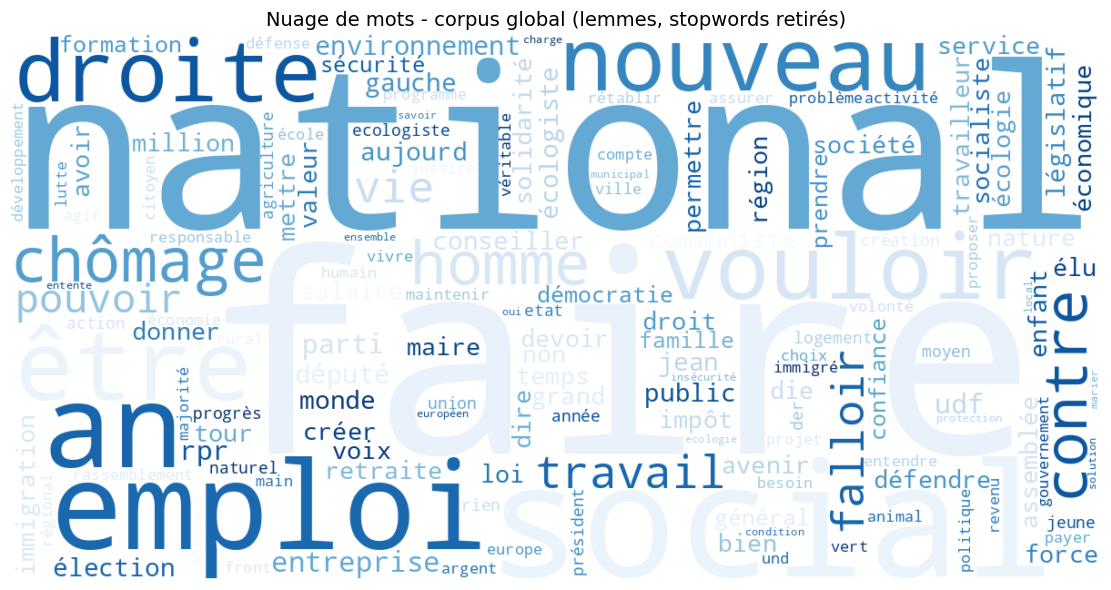

In [20]:
from wordcloud import WordCloud
from collections import Counter

# - 1. Nuage global -----------------------------
all_tokens = [t for tokens in df_clean["tokens"] for t in tokens]
freq_global = Counter(all_tokens)

wc_global = WordCloud(
    width=1200, height=600,
    background_color="white",
    colormap="Blues",
    max_words=150,
    collocations=False
).generate_from_frequencies(freq_global)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc_global, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nuage de mots - corpus global (lemmes, stopwords retirés)", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/01_wordcloud_global.png", dpi=150, bbox_inches="tight")
plt.show()

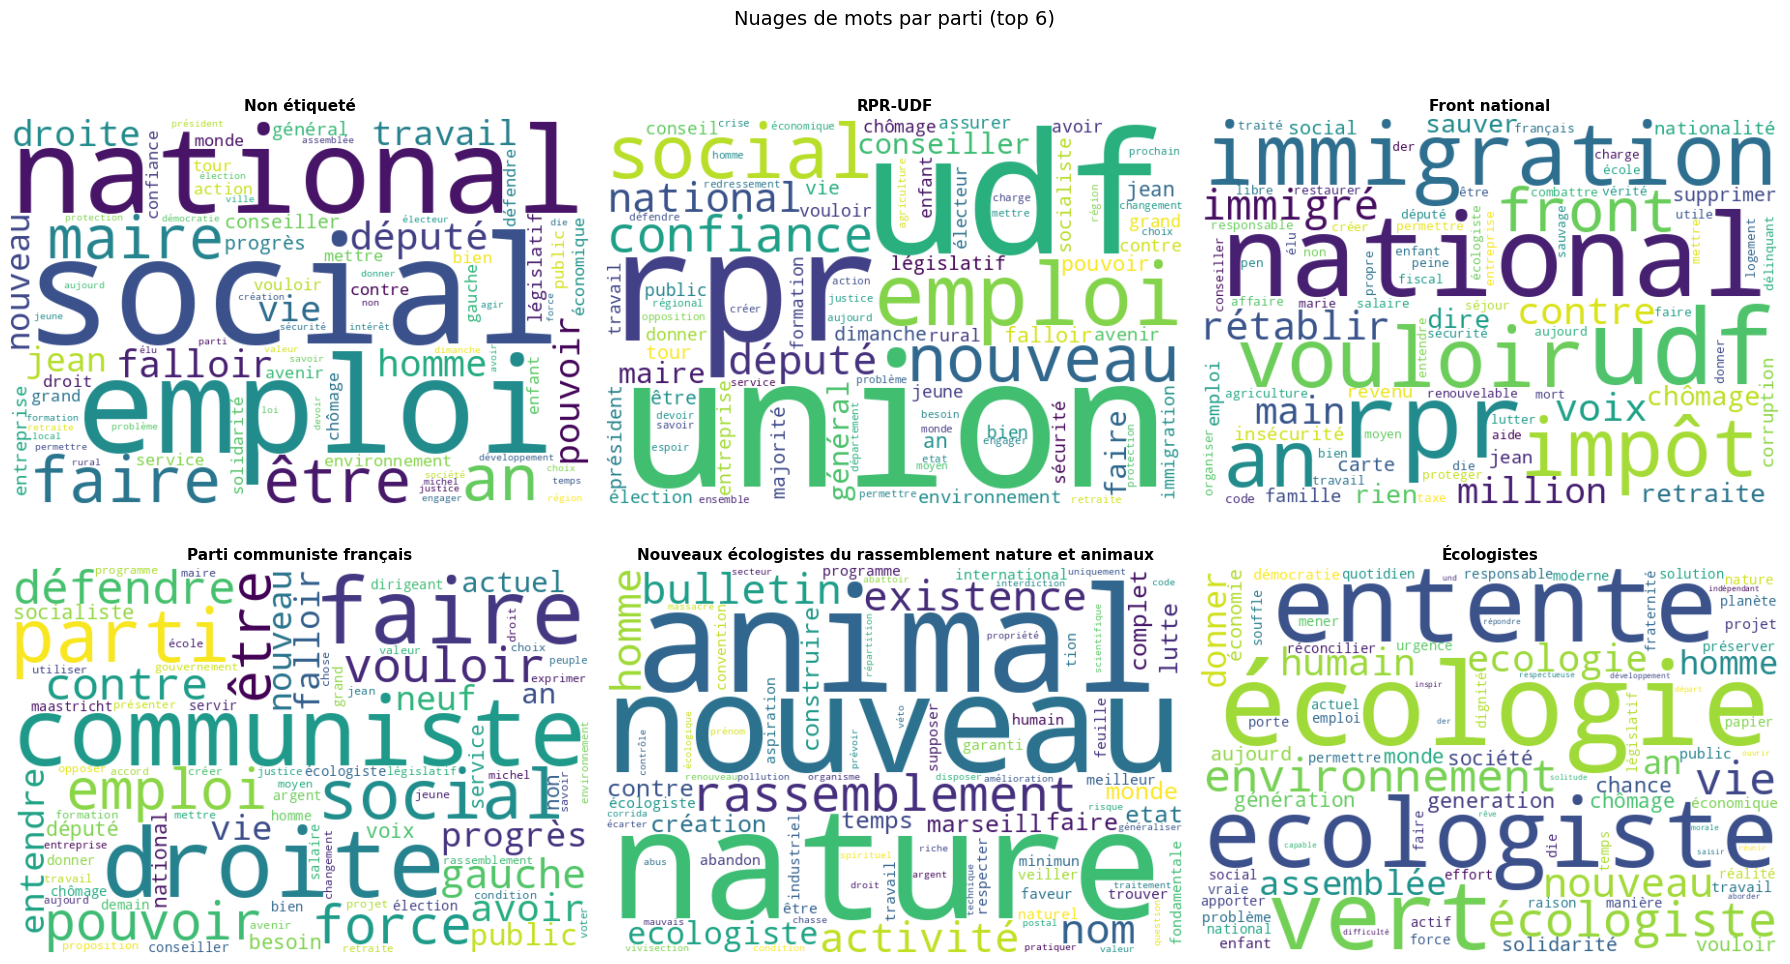

In [21]:
# - 2. Nuages par parti (pour les partis majeurs) -------------─
partis_majeurs = [p for p in df_clean["titulaire-soutien-simplifie"].value_counts().index
                  if p != "Autre / indépendant"][:6]  # top 6

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, parti in zip(axes, partis_majeurs):
    tokens_parti = [
        t
        for tokens in df_clean[df_clean["titulaire-soutien-simplifie"] == parti]["tokens"]
        for t in tokens
    ]
    freq_parti = Counter(tokens_parti)
    wc = WordCloud(
        width=600, height=400,
        background_color="white",
        colormap="viridis",
        max_words=80,
        collocations=False
    ).generate_from_frequencies(freq_parti)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(parti, fontsize=11, fontweight="bold")

plt.suptitle("Nuages de mots par parti (top 6)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/01_wordcloud_partis.png", dpi=150, bbox_inches="tight")
plt.show()


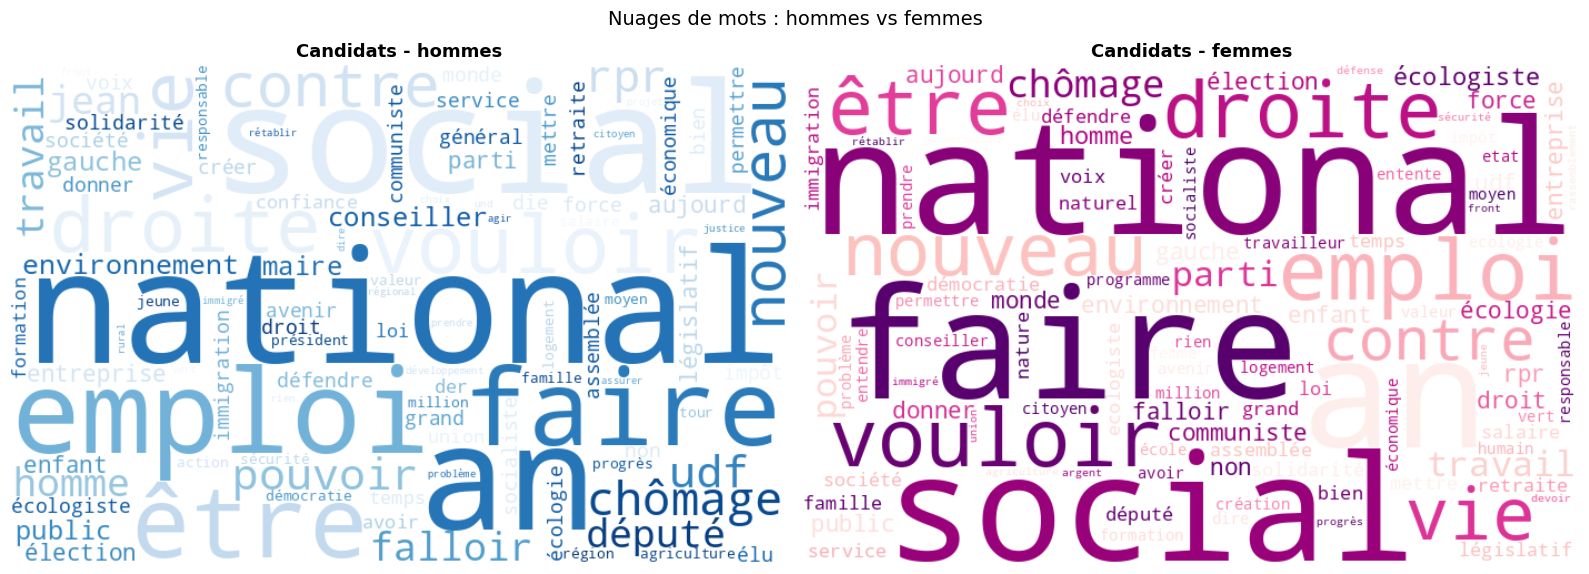

In [22]:
# - 3. Nuage hommes vs femmes ------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sexe, cmap in zip(axes, ["homme", "femme"], ["Blues", "RdPu"]):
    tokens_sexe = [
        t
        for tokens in df_clean[df_clean["titulaire-sexe"] == sexe]["tokens"]
        for t in tokens
    ]
    freq_sexe = Counter(tokens_sexe)
    wc = WordCloud(
        width=700, height=450,
        background_color="white",
        colormap=cmap,
        max_words=100,
        collocations=False
    ).generate_from_frequencies(freq_sexe)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Candidats - {sexe}s", fontsize=13, fontweight="bold")

plt.suptitle("Nuages de mots : hommes vs femmes", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/01_wordcloud_genre.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.1 Distribution par parti (soutien/coalition politique)

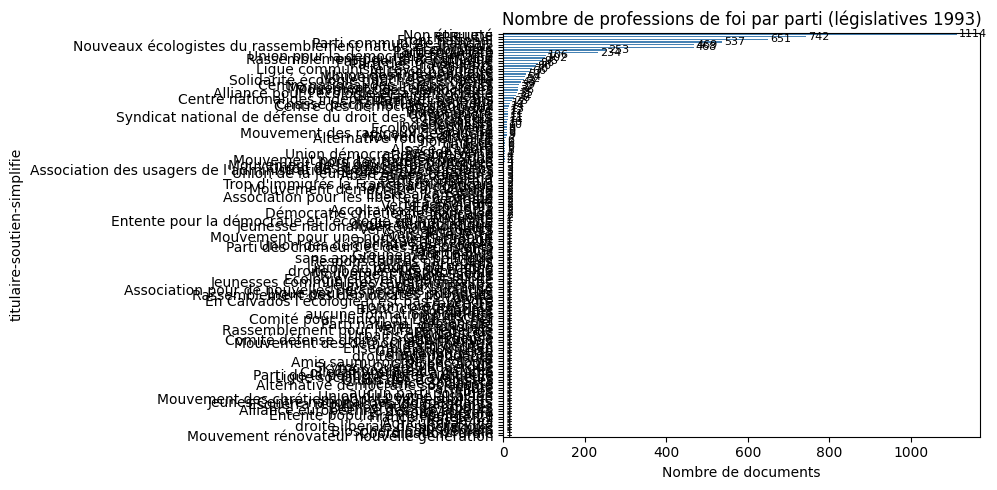

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
parti_counts = df_clean["titulaire-soutien-simplifie"].value_counts()
parti_counts.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Nombre de documents")
ax.set_title("Nombre de professions de foi par parti (législatives 1993)")
for i, v in enumerate(parti_counts.sort_values()):
    ax.text(v + 5, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.savefig("../figures/01_dist_partis.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.2 Répartition par sexe

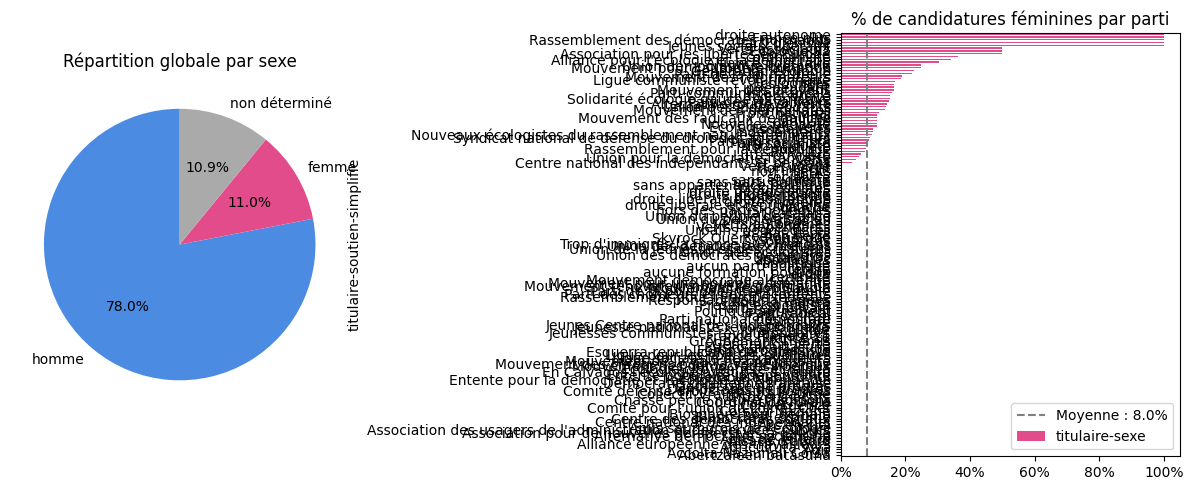

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Global
sexe_counts = df_clean["titulaire-sexe"].value_counts()
sexe_counts.plot.pie(ax=axes[0], autopct="%1.1f%%", startangle=90,
                     colors=["#4C8BE2", "#E24C8B", "#AAAAAA"])
axes[0].set_title("Répartition globale par sexe")
axes[0].set_ylabel("")

# Par parti (% femmes)
pct_femmes = (
    df_clean.groupby("titulaire-soutien-simplifie")["titulaire-sexe"]
    .apply(lambda s: (s == "femme").mean() * 100)
    .sort_values()
)
pct_femmes.plot.barh(ax=axes[1], color="#E24C8B")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("% de candidatures féminines par parti")
axes[1].axvline(x=pct_femmes.mean(), color="gray", linestyle="--", label=f"Moyenne : {pct_femmes.mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/01_dist_sexe.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.3 Distribution de la longueur des textes

TypeError: can only concatenate list (not "int") to list

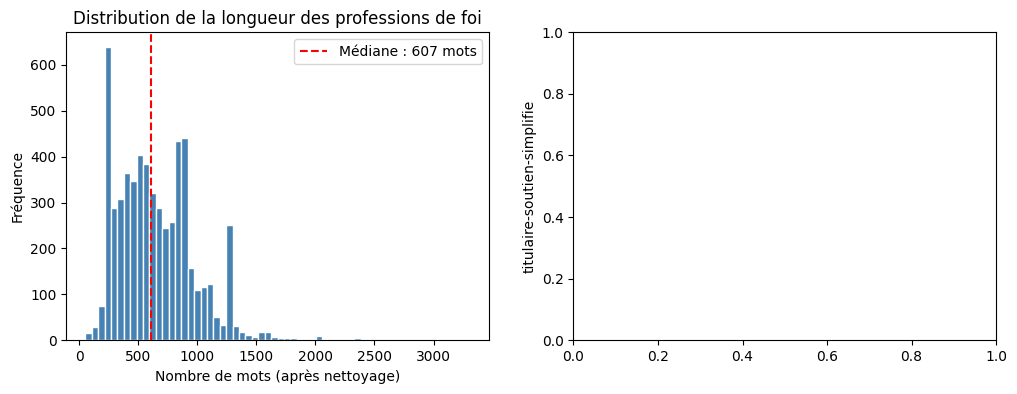

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme global
axes[0].hist(df_clean["n_words_clean_text_lda"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Nombre de mots (après nettoyage)")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Distribution de la longueur des professions de foi")
axes[0].axvline(df_clean["n_words_clean_text_lda"].median(), color="red", linestyle="--",
                label=f"Médiane : {df_clean['n_words_clean_text_lda'].median():.0f} mots")
axes[0].legend()

# Boxplot par parti
order = (df_clean.groupby("titulaire-soutien-simplifie")["n_words_clean_text_lda"]
         .median().sort_values().index.tolist())
df_clean.boxplot(column="n_words_clean_text_lda", by="titulaire-soutien-simplifie",
                 ax=axes[1], vert=False, zorder=order,
                 medianprops=dict(color="red"))
axes[1].set_title("Longueur par parti")
axes[1].set_xlabel("Nombre de mots")
plt.suptitle("")

plt.tight_layout()
plt.savefig("../figures/01_longueur_textes.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_clean[["n_words_clean_text_lda", "n_tokens"]].describe().round(1))

## 6.4 Richesse lexicale (Type-Token Ratio)

Le TTR mesure la diversité du vocabulaire utilisé par chaque document. Il est sensible à la longueur du texte, donc on va le calculer sur une fenêtre fixe de 100 tokens (MSTTR).

In [ ]:
WINDOW = 100

def msttr(tokens: list, window: int = WINDOW) -> float:
    """Mean Segmental TTR sur des fenêtres de longueur fixe."""
    if len(tokens) < window:
        return len(set(tokens)) / len(tokens) if tokens else 0.0
    windows = [tokens[i:i+window] for i in range(0, len(tokens) - window + 1, window)]
    return np.mean([len(set(w)) / window for w in windows])

df_clean["msttr"] = df_clean["tokens"].apply(msttr)

print("MSTTR moyen par parti:")
print(df_clean.groupby("titulaire-soutien-simplifie")["msttr"].mean().sort_values(ascending=False).round(3))

MSTTR moyen par parti:
titulaire-soutien-simplifie
Mouvement des démocrates libéraux         0.968
Parti national démocrate                  0.937
Agir                                      0.930
Entente populaire indépendante            0.930
Parti de la politique inter-culturelle    0.925
                                          ...  
Amis de la Terre                          0.765
Agricultura Viva                          0.760
Alsace d'abord                            0.754
Politique autrement                       0.740
Trop d'immigrés la France aux Français    0.736
Name: msttr, Length: 152, dtype: float64


## 6.5 Vocabulaire global et top mots fréquents

Taille du vocabulaire total (lemmes) : 50,511
Tokens totaux : 1,750,874

Top 30 lemmes les plus fréquents :
[('faire', 12636), ('national', 10931), ('social', 10717), ('emploi', 10560), ('an', 9813), ('être', 8921), ('vouloir', 8283), ('nouveau', 7882), ('droite', 7390), ('chômage', 7207), ('homme', 7042), ('contre', 6833), ('travail', 6791), ('vie', 6499), ('falloir', 6423), ('pouvoir', 6325), ('entreprise', 6091), ('rpr', 5762), ('député', 5730), ('udf', 5610), ('parti', 5609), ('environnement', 5366), ('élection', 5183), ('monde', 5100), ('législatif', 4973), ('jean', 4969), ('écologiste', 4832), ('public', 4804), ('gauche', 4725), ('aujourd', 4720)]


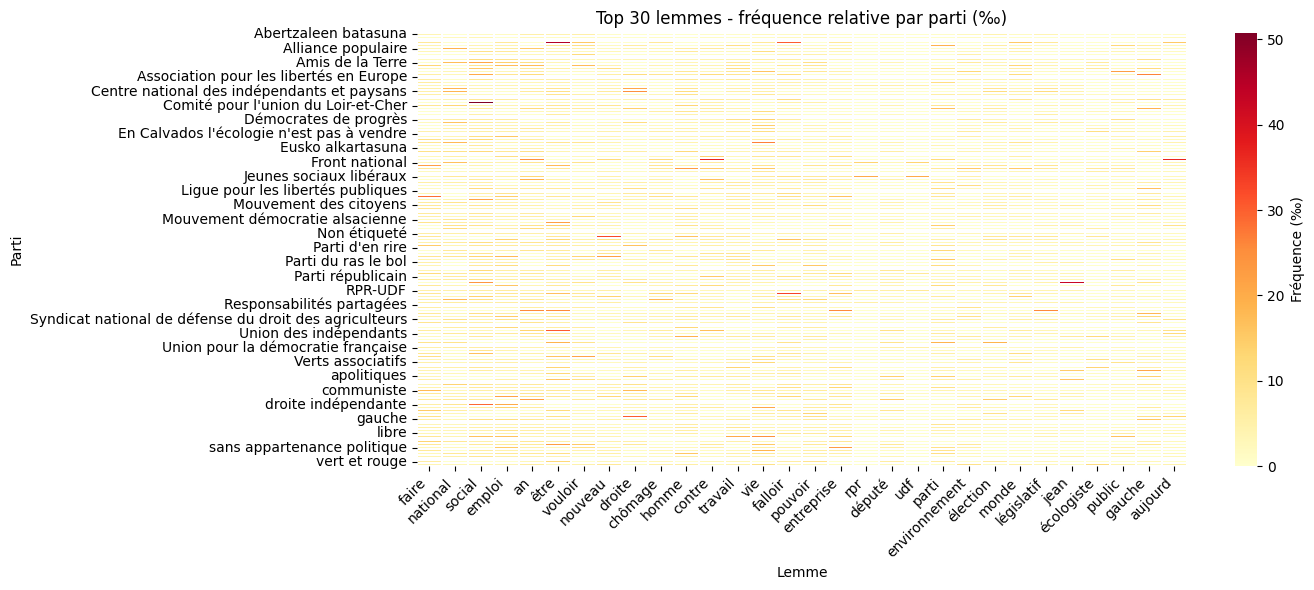

In [ ]:
from collections import Counter

all_tokens = [t for tokens in df_clean["tokens"] for t in tokens]
vocab = Counter(all_tokens)

print(f"Taille du vocabulaire total (lemmes) : {len(vocab):,}")
print(f"Tokens totaux : {len(all_tokens):,}")
print(f"\nTop 30 lemmes les plus fréquents :")
print(vocab.most_common(30))

# Heatmap top mots par parti
top_words = [w for w, _ in vocab.most_common(30)]

# Fréquence relative par parti
heatmap_data = {}
for parti, grp in df_clean.groupby("titulaire-soutien-simplifie"):
    parti_tokens = [t for toks in grp["tokens"] for t in toks]
    total = len(parti_tokens)
    if total == 0:
        continue
    c = Counter(parti_tokens)
    heatmap_data[parti] = {w: c.get(w, 0) / total * 1000 for w in top_words}  # pour mille

df_heatmap = pd.DataFrame(heatmap_data).T

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(df_heatmap, cmap="YlOrRd", ax=ax, linewidths=0.3,
            cbar_kws={"label": "Fréquence (‰)"})
ax.set_title("Top 30 lemmes - fréquence relative par parti (‰)")
ax.set_xlabel("Lemme")
ax.set_ylabel("Parti")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/01_heatmap_vocab.png", dpi=150, bbox_inches="tight")
plt.show()

# 7. Sauvegarde du corpus préparé. 
On sauvegarde le DataFrame (sans les tokens, car trop lourd) et les tokens séparément.

In [2]:
import os
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# DataFrame principal (sans tokens pour alléger)
cols_to_save = [
    "id", "titulaire-sexe", "titulaire-profession", "titulaire-soutien",
    "parti_principal", "parti_simplifie",
    "raw_text", "clean_text",
    "n_chars_raw", "n_words_clean", "n_tokens", "msttr",
    "departement-nom", "contexte-tour"
]
df_clean[cols_to_save].to_csv("../data/processed/corpus_1993.csv", index=False)
print("Sauvegardé : data/processed/corpus_1993.csv")

# Tokens (JSON, un doc par ligne)
with open("../data/processed/tokens_1993.jsonl", "w", encoding="utf-8") as f:
    for row in df_clean[["id", "tokens"]].itertuples():
        f.write(json.dumps({"id": row.id, "tokens": row.tokens}, ensure_ascii=False) + "\n")
print("Sauvegardé : data/processed/tokens_1993.jsonl")

print(f"\n--- Résumé du corpus ---")
print(f"Documents total       : {len(df_clean)}")
print(f"Documents hommes      : {(df_clean['titulaire-sexe']=='homme').sum()}")
print(f"Documents femmes      : {(df_clean['titulaire-sexe']=='femme').sum()}")
print(f"Documents non déterm. : {(df_clean['titulaire-sexe']=='non déterminé').sum()}")
print(f"Partis représentés    : {df_clean['titulaire-soutien-simplifie'].nunique()}")
print(f"Tokens moyens/doc     : {df_clean['n_tokens'].mean():.0f}")
print(f"Taille du vocabulaire : {len(vocab):,}")

NameError: name 'df_clean' is not defined